In [51]:
import numpy as np
import pandas as pd
import matplotlib as plt
df= pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [53]:
df.shape

(918, 12)

In [54]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [55]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

## Column Description

- **Age**: Patient age in years.
- **Sex**: Patient gender. `M` means male and `F` means female.
- **ChestPainType**: Type of chest pain. Examples: `TA`, `ATA`, `NAP`, `ASY`.
- **RestingBP**: Blood pressure while the patient is resting.
- **Cholesterol**: Cholesterol level in the blood.
- **FastingBS**: Fasting blood sugar. `1` means above 120 mg/dl, `0` means not above 120 mg/dl.
- **RestingECG**: ECG result while the patient is resting.
- **MaxHR**: Maximum heart rate achieved during exercise.
- **ExerciseAngina**: Whether exercise causes chest pain. `Y` means yes, `N` means no.
- **Oldpeak**: ST depression value after exercise compared to rest.
- **ST_Slope**: Slope of the ST segment during exercise.
- **HeartDisease**: The target column. `1` means heart disease, `0` means no heart disease.

In [56]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [57]:
df["HeartDisease"].value_counts(normalize=True)*100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [58]:
df.groupby("HeartDisease")["Age"].mean()

HeartDisease
0    50.551220
1    55.899606
Name: Age, dtype: float64

In [59]:
df.groupby("HeartDisease")["Cholesterol"].mean()

HeartDisease
0    227.121951
1    175.940945
Name: Cholesterol, dtype: float64

## Data Cleaning / Detecting Hidden Missing Values

In [60]:
(df["Cholesterol"]==0).sum()

np.int64(172)

In [61]:
(df["RestingBP"]==0).sum()

np.int64(1)

In [62]:
df=df[df["RestingBP"]!=0]

In [63]:
df["Cholesterol"]=df["Cholesterol"].replace(0,np.nan)
(df["Cholesterol"]==0).sum()

np.int64(0)

df["Cholesterol"].median()## Data Cleaning Decision: Hidden Missing Values

During the EDA step, we found that some medical columns contain unrealistic zero values:

- `Cholesterol = 0` appeared in 172 rows.
- `RestingBP = 0` appeared in 1 row.

These values are not medically realistic, so we treat them as hidden missing values.

### Cleaning Decision

For `RestingBP`, there is only one invalid row, so I decided to remove it.

For `Cholesterol`, there are many zero values, so deleting all of them would remove too much data.  
Instead, I replaced the zero values with `NaN`.

However, I decided **not to use simple median imputation directly on the full dataset**, because this would be less professional and may cause data leakage if done before splitting the data.

The better approach is:

1. Replace invalid zero values with `NaN`.
2. Split the data into training and testing sets.
3. Apply imputation only inside a preprocessing pipeline.
4. Compare more advanced imputation methods such as:
   - `KNNImputer`
   - `IterativeImputer`
   - Median imputation as a baseline

This makes the workflow more realistic and closer to how an ML Engineer handles missing values.

## Feature Encoding / Categorical Encoding

In [65]:
df["Sex"]=df["Sex"].map({
    "M":1,
    "F":0
})
df["Sex"].value_counts()

Sex
1    724
0    193
Name: count, dtype: int64

In [66]:
df["Sex"].isnull().sum()

np.int64(0)

In [67]:
df["ExerciseAngina"]=df["ExerciseAngina"].map({
    "Y":1,
    "N":0
})
df["ExerciseAngina"].value_counts()

ExerciseAngina
0    546
1    371
Name: count, dtype: int64

In [68]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    459
Up      395
Down     63
Name: count, dtype: int64

In [69]:
df["ST_Slope"]=df["ST_Slope"].map({
    "Up": 0,
    "Flat": 1,
    "Down": 2
})
df["ST_Slope"].value_counts()

ST_Slope
1    459
0    395
2     63
Name: count, dtype: int64

In [70]:
df=pd.get_dummies(df,columns=["ChestPainType","RestingECG"],drop_first=True, dtype=int)

In [71]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289.0,0,172,0,0.0,0,0,1,0,0,1,0
1,49,0,160,180.0,0,156,0,1.0,1,1,0,1,0,1,0
2,37,1,130,283.0,0,98,0,0.0,0,0,1,0,0,0,1
3,48,0,138,214.0,0,108,1,1.5,1,1,0,0,0,1,0
4,54,1,150,195.0,0,122,0,0.0,0,0,0,1,0,1,0


In [72]:
df.shape

(917, 15)

## Train/Test Split

In [81]:
X=df.drop("HeartDisease",axis=1)
y=df["HeartDisease"]

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,# keeps the same class ratio (0 and 1) in both train and test
    random_state=42
)


In [82]:

# Verify stratify worked correctly (ratios should be close between train and test)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

HeartDisease
1    0.552524
0    0.447476
Name: proportion, dtype: float64
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


## Preprocessing: Scaling Before KNN Imputation

In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled = scaler.transform(X_test) 

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train_scaled) # learn only from train
X_test_imputed = imputer.transform(X_test_scaled)    


#Convert the processed arrays back to DataFrames
X_train_processed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)


In [87]:
print("Missing values in X_train:", X_train_processed.isnull().sum().sum())
print("Missing values in X_test:", X_test_processed.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [88]:
X_train_processed.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
161,-0.504752,0.509363,-0.271661,-0.571707,-0.551607,-1.590143,1.218501,-0.813322,0.615473,-0.47729,-0.522082,-0.23383,0.813715,-0.488032
604,1.505450,0.509363,0.055941,0.135690,1.812884,0.557626,1.218501,-0.813322,-1.055423,-0.47729,1.915409,-0.23383,0.813715,-0.488032
659,0.553249,0.509363,-0.380862,-0.470650,1.812884,-0.106230,-0.820680,1.244032,0.615473,-0.47729,1.915409,-0.23383,0.813715,-0.488032
793,1.399650,0.509363,-0.435463,0.135690,1.812884,1.026231,-0.820680,-0.626290,0.615473,-0.47729,-0.522082,-0.23383,0.813715,-0.488032
140,-0.187351,0.509363,1.475552,1.432585,-0.551607,-1.668244,1.218501,1.524581,0.615473,-0.47729,-0.522082,-0.23383,0.813715,-0.488032


# Scaling is useful for distance-based and linear models such as Logistic Regression, SVM, and KNN,
 because these models are affected by feature ranges.
 It is less important for tree-based models like Decision Tree, Random Forest, and Gradient Boosting,
 because they split data based on feature thresholds, not distances.
 After preprocessing, we should use X_train_processed and X_test_processed for model training.

## Baseline Model: Logistic Regression

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score, recall_score,precision_score
model =LogisticRegression(max_iter=1000)
model.fit(X_train_processed,y_train)
y_pred=model.predict(X_test_processed)


accuracy=accuracy_score(y_test,y_pred)
recall= recall_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

print("Accuracy : ",accuracy)
print("Recall : ",recall)
print("Precision : ",precision)
print("F1 : ",f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy :  0.8695652173913043
Recall :  0.9117647058823529
Precision :  0.8611111111111112
F1 :  0.8857142857142857

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184


Confusion Matrix:
[[67 15]
 [ 9 93]]


<Figure size 800x600 with 0 Axes>

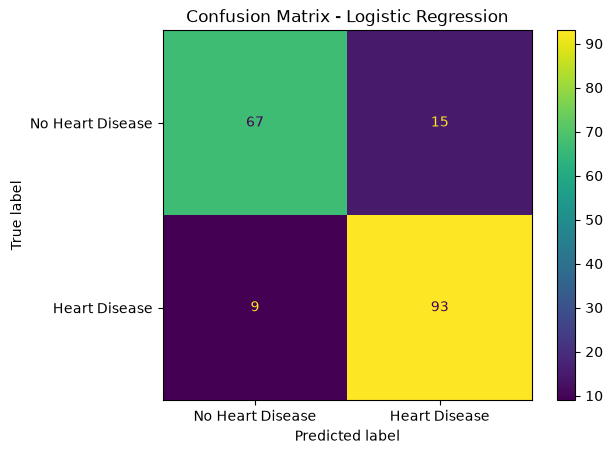

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Baseline Model Evaluation

The baseline Logistic Regression model achieved good performance.

Accuracy was around 87%, meaning the model predicted most test cases correctly.

Recall for the positive class was about 91%, which is very important in a medical problem because missing a patient with heart disease can be risky.

The confusion matrix showed 9 false negatives, meaning 9 patients with heart disease were incorrectly predicted as healthy.

Overall, the baseline model is strong, but the next step is to compare it with other models and use cross-validation to check if the performance is stable.

## Cross-Validation

In [102]:
from sklearn.model_selection import cross_val_score
model = LogisticRegression(max_iter=1000)
recall_scores=cross_val_score(
    model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="recall"
)


print("Recall scores:", recall_scores)
print("Mean Recall:", recall_scores.mean())
print("Std Recall:", recall_scores.std())

Recall scores: [0.85185185 0.9382716  0.85185185 0.82716049 0.80246914]
Mean Recall: 0.8543209876543211
Std Recall: 0.045795646891336785


In [103]:
roc_auc_scores = cross_val_score(
    model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC scores:", roc_auc_scores)
print("Mean ROC-AUC:", roc_auc_scores.mean())
print("Std ROC-AUC:", roc_auc_scores.std())

ROC-AUC scores: [0.93135054 0.95828657 0.92648709 0.87654321 0.85261159]
Mean ROC-AUC: 0.9090558001669112
Std ROC-AUC: 0.038646065762928686


## Model Comparison

In [108]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Define evaluation metrics
scoring = {
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

results = []

# Evaluate each model using cross-validation
for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train_processed,
        y_train,
        cv=5,
        scoring=scoring
    )
    
    results.append({
        "Model": model_name,
        "Mean Recall": scores["test_recall"].mean(),
        "Mean F1": scores["test_f1"].mean(),
        "Mean ROC-AUC": scores["test_roc_auc"].mean(),
        "Mean Accuracy": scores["test_accuracy"].mean()
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by Recall because recall is the most important metric in this medical problem
results_df = results_df.sort_values(by="Mean Recall", ascending=False)

results_df

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.1

,Model,Mean Recall,Mean F1,Mean ROC-AUC,Mean Accuracy
4,Gradient Boosting,0.881481,0.876687,0.918063,0.863461
1,SVM,0.879012,0.863208,0.911192,0.845746
3,Random Forest,0.876543,0.868862,0.920585,0.853928
2,KNN,0.864198,0.855790,0.888060,0.838953
0,Logistic Regression,0.854321,0.851061,0.909056,0.834815


The Logistic Regression model achieved higher recall on the single test split, but its mean recall was lower during cross-validation.

This difference is expected because a single train-test split can be optimistic or depend on how the data was divided.

Cross-validation gives a more reliable estimate because it evaluates the model across multiple different splits.

Therefore, the cross-validation mean recall is a better indicator of the model's real performance.

## Model Comparison Results

I compared several classification models using 5-fold cross-validation.

Since this is a medical classification problem, the main metric I focused on was **Recall**, because false negatives are dangerous. A false negative means a patient with heart disease is predicted as healthy.

The best model based on mean recall was **Gradient Boosting**, with a mean recall of about **88%**.

Random Forest achieved the highest ROC-AUC score, which means it has strong ability to separate heart disease cases from non-heart disease cases. However, Gradient Boosting had slightly better recall, so it is the best candidate for hyperparameter tuning.

Overall, Gradient Boosting and Random Forest performed better than the baseline Logistic Regression model.

## Hyperparameter Tuning with GridSearchCV

In [116]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Recall Score:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best Recall Score: 0.893827160493827


In [118]:
best_gb_model = grid_search.best_estimator_
y_pred_gb = best_gb_model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred_gb)
recall = recall_score(y_test, y_pred_gb)
precision = precision_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))



Accuracy: 0.8586956521739131
Recall: 0.8921568627450981
Precision: 0.8584905660377359
F1: 0.875

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        82
           1       0.86      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184


Confusion Matrix:
[[67 15]
 [11 91]]


## Professional Cross-Validation with Pipeline

In the previous approach, preprocessing was applied before cross-validation.  
This can cause slight data leakage because the scaler and imputer see the whole training set before the folds are created.

To make the evaluation more professional, I used a full pipeline that includes:

- StandardScaler
- KNNImputer
- Logistic Regression

During cross-validation, each fold fits the preprocessing steps only on its own training part.  
This gives a more reliable estimate of the model performance.

In [123]:
from sklearn.pipeline import Pipeline

# Create a full pipeline: scaling + imputation + model
logistic_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("model", LogisticRegression(max_iter=1000))
])

scoring = {
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

print("Mean Recall:", cv_results["test_recall"].mean())
print("Mean F1:", cv_results["test_f1"].mean())
print("Mean ROC-AUC:", cv_results["test_roc_auc"].mean())
print("Mean Accuracy:", cv_results["test_accuracy"].mean())

Mean Recall: 0.8543209876543211
Mean F1: 0.8510606886146782
Mean ROC-AUC: 0.9087173731618176
Mean Accuracy: 0.8348150218991707


In [125]:
from sklearn.pipeline import Pipeline

# Create a full pipeline: scaling + KNN imputation + Gradient Boosting
gb_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("model", GradientBoostingClassifier(random_state=42))
])

scoring = {
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

gb_cv_results = cross_validate(
    gb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)
# cross_validate fits the pipeline internally on each training fold.
# In each fold, the scaler, imputer, and model are fitted only on the fold's training data.
# This is used for evaluation only.
# After choosing the final model, we still need to fit the pipeline on the full training set.
print("Mean Recall:", gb_cv_results["test_recall"].mean())
print("Mean F1:", gb_cv_results["test_f1"].mean())
print("Mean ROC-AUC:", gb_cv_results["test_roc_auc"].mean())
print("Mean Accuracy:", gb_cv_results["test_accuracy"].mean())

Mean Recall: 0.8765432098765432
Mean F1: 0.8749909093023867
Mean ROC-AUC: 0.9182232582232583
Mean Accuracy: 0.8621004566210045


## Fit Final Gradient Boosting Pipeline and Evaluate on Test Set

In [128]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fit the final Gradient Boosting pipeline on the full training data
gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gb)
recall = recall_score(y_test, y_pred_gb)
precision = precision_score(y_test, y_pred_gb)
f1 = f1_score(y_test, y_pred_gb)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy: 0.8695652173913043
Recall: 0.8725490196078431
Precision: 0.89
F1: 0.8811881188118812

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        82
           1       0.89      0.87      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Confusion Matrix:
[[71 11]
 [13 89]]


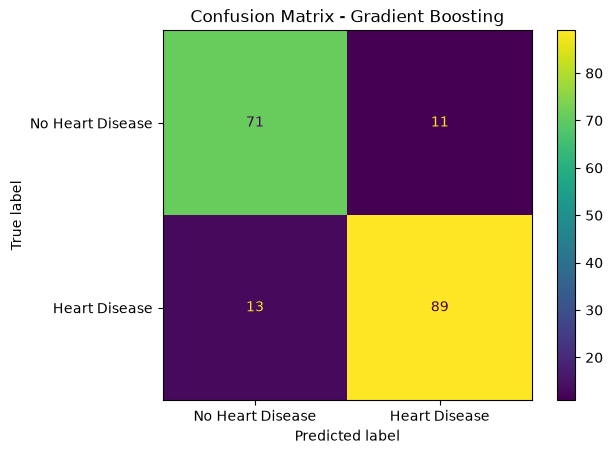

In [129]:
# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gb,
    display_labels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

<Figure size 800x600 with 0 Axes>

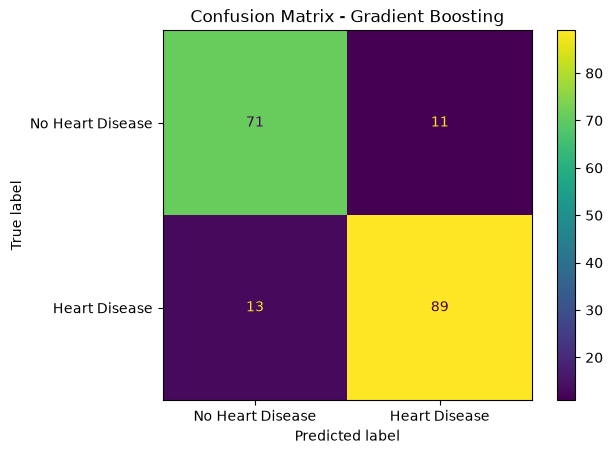

In [133]:
plt.figure(figsize=(8,6))
cm=confusion_matrix(y_test,y_pred_gb)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)
disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()


## Threshold Tuning

In [134]:
y_proba_gb=gb_pipeline.predict_proba(X_test)[:,1]
thresholds=[0.30,0.35,0.40,0.45,0.50]
for threshold in thresholds:
    y_pred_threshold=(y_proba_gb>=threshold).astype(int)
    cm=confusion_matrix(y_test,y_pred_threshold)
    tn,fp,fn,tp=cm.ravel()
    print("Threshold:", threshold)
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("F1:", f1_score(y_test, y_pred_threshold))
    print("False Negatives:", fn)
    print("False Positives:", fp)
    print("-" * 30)
    


Threshold: 0.3
Recall: 0.9117647058823529
Precision: 0.8454545454545455
F1: 0.8773584905660378
False Negatives: 9
False Positives: 17
------------------------------
Threshold: 0.35
Recall: 0.8921568627450981
Precision: 0.8425925925925926
F1: 0.8666666666666667
False Negatives: 11
False Positives: 17
------------------------------
Threshold: 0.4
Recall: 0.8921568627450981
Precision: 0.875
F1: 0.883495145631068
False Negatives: 11
False Positives: 13
------------------------------
Threshold: 0.45
Recall: 0.8823529411764706
Precision: 0.8910891089108911
F1: 0.8866995073891626
False Negatives: 12
False Positives: 11
------------------------------
Threshold: 0.5
Recall: 0.8725490196078431
Precision: 0.89
F1: 0.8811881188118812
False Negatives: 13
False Positives: 11
------------------------------


## Threshold Tuning Results

The default classification threshold is 0.50.  
However, in a medical classification problem, false negatives are more dangerous than false positives.

A false negative means that a patient with heart disease is predicted as healthy.

After testing different thresholds, the threshold of **0.30** achieved the highest recall:

- Recall: 91.2%
- False Negatives: 9
- False Positives: 17

Compared to the default threshold of 0.50:

- Recall: 87.3%
- False Negatives: 13
- False Positives: 11

Therefore, I selected **0.30** as the preferred threshold because it reduces the number of missed heart disease patients.

In [135]:
# Use the selected threshold for final predictions
selected_threshold = 0.30

y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_gb >= selected_threshold).astype(int)

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83        82
           1       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184

[[65 17]
 [ 9 93]]


## Error Analysis: False Negatives

In [137]:
error_analysis= X_test.copy()
error_analysis["y_true"]=y_test
error_analysis["y_pred"]=y_pred_final
error_analysis["heart_disease_probability"]= y_proba_gb 
false_negatives=error_analysis[
    (error_analysis["y_true"]==1)&
    (error_analysis["y_pred"] == 0)
]
false_negatives

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,y_true,y_pred,heart_disease_probability
645,57,1,128,229.0,0,150,0,0.4,1,0,1,0,0,0,1,0,0.180465
1,49,0,160,180.0,0,156,0,1.0,1,0,1,0,1,0,1,0,0.150251
652,59,1,160,273.0,0,125,0,0.0,0,0,0,1,0,0,1,0,0.137213
912,57,0,140,241.0,0,123,1,0.2,1,0,0,0,1,0,1,0,0.287142
889,59,1,134,204.0,0,162,0,0.8,0,0,0,1,1,0,1,0,0.168906
617,57,1,124,261.0,0,141,0,0.3,0,1,0,0,1,0,1,0,0.049675
757,50,1,140,233.0,0,163,0,0.6,1,0,1,0,1,0,1,0,0.117390
879,48,1,110,229.0,0,168,0,1.0,2,1,0,0,1,0,1,0,0.219445
316,57,1,105,NaN,1,148,0,0.3,1,0,1,0,1,0,1,0,0.242573


In [138]:
false_negatives.describe()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,y_true,y_pred,heart_disease_probability
count,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.0,9.0,9.0,9.000000
mean,54.777778,0.777778,133.444444,231.250000,0.111111,148.444444,0.111111,0.511111,0.777778,0.222222,0.444444,0.222222,0.777778,0.0,1.0,0.0,0.172562
std,4.437842,0.440959,19.281540,29.533274,0.333333,16.164089,0.333333,0.358624,0.666667,0.440959,0.527046,0.440959,0.440959,0.0,0.0,0.0,0.070884
min,48.000000,0.000000,105.000000,180.000000,0.000000,123.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.049675
25%,50.000000,1.000000,124.000000,222.750000,0.000000,141.000000,0.000000,0.300000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.137213
50%,57.000000,1.000000,134.000000,231.000000,0.000000,150.000000,0.000000,0.400000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.168906
75%,57.000000,1.000000,140.000000,246.000000,0.000000,162.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000,1.000000,0.0,1.0,0.0,0.219445
max,59.000000,1.000000,160.000000,273.000000,1.000000,168.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.0,0.0,0.287142


In [139]:
# Compare false negatives with all actual heart disease cases
actual_positive_cases = error_analysis[error_analysis["y_true"] == 1]

print("False Negatives:")
display(false_negatives.describe())

print("All Actual Heart Disease Cases:")
display(actual_positive_cases.describe())

False Negatives:


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,y_true,y_pred,heart_disease_probability
count,9.000000,9.000000,9.000000,8.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.0,9.0,9.0,9.000000
mean,54.777778,0.777778,133.444444,231.250000,0.111111,148.444444,0.111111,0.511111,0.777778,0.222222,0.444444,0.222222,0.777778,0.0,1.0,0.0,0.172562
std,4.437842,0.440959,19.281540,29.533274,0.333333,16.164089,0.333333,0.358624,0.666667,0.440959,0.527046,0.440959,0.440959,0.0,0.0,0.0,0.070884
min,48.000000,0.000000,105.000000,180.000000,0.000000,123.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.049675
25%,50.000000,1.000000,124.000000,222.750000,0.000000,141.000000,0.000000,0.300000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.137213
50%,57.000000,1.000000,134.000000,231.000000,0.000000,150.000000,0.000000,0.400000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.168906
75%,57.000000,1.000000,140.000000,246.000000,0.000000,162.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000,1.000000,0.0,1.0,0.0,0.219445
max,59.000000,1.000000,160.000000,273.000000,1.000000,168.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.0,0.0,0.287142


All Actual Heart Disease Cases:


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,y_true,y_pred,heart_disease_probability
count,102.000000,102.000000,102.000000,67.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.0,102.000000,102.000000
mean,56.352941,0.901961,133.382353,254.179104,0.333333,127.901961,0.656863,1.440196,0.921569,0.049020,0.166667,0.039216,0.598039,0.235294,1.0,0.911765,0.793889
std,7.745516,0.298836,17.123341,66.973746,0.473732,21.322377,0.477101,1.115353,0.539275,0.216975,0.374518,0.195066,0.492715,0.426277,0.0,0.285037,0.247448
min,34.000000,0.000000,95.000000,153.000000,0.000000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.049675
25%,51.000000,1.000000,120.000000,210.000000,0.000000,112.250000,0.000000,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,0.680439
50%,57.000000,1.000000,132.000000,243.000000,0.000000,125.500000,1.000000,1.500000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0,1.000000,0.906263
75%,62.000000,1.000000,141.500000,284.000000,1.000000,142.750000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0,1.000000,0.958827
max,75.000000,1.000000,185.000000,518.000000,1.000000,180.000000,1.000000,5.600000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,0.989336


## False Negative Error Analysis

In this step, I analyzed the patients who were incorrectly predicted as healthy even though they actually had heart disease.

These cases are called false negatives:

- `y_true = 1`
- `y_pred = 0`

False negatives are the most important errors in this medical classification problem because they represent missed heart disease patients.

The false negative table showed 9 missed patients after applying the selected threshold of 0.30.

By comparing false negatives with all actual heart disease cases, I noticed that the missed patients had weaker disease signals:

- Their average MaxHR was higher than the average MaxHR of all heart disease patients.
- Most of them did not have exercise-induced angina.
- Their Oldpeak values were lower.
- Their predicted probabilities were below the selected threshold.

This suggests that the model struggles with heart disease patients who do not show strong typical risk patterns.

These cases are clinically important because they look less risky in the dataset, but they still have heart disease.

## Feature Engineering Based on Error Analysis

In [142]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

maxhr_median = X_train_fe["MaxHR"].median()
oldpeak_median = X_train_fe["Oldpeak"].median()

X_train_fe["High_MaxHR"] = (X_train_fe["MaxHR"] > maxhr_median).astype(int)
X_test_fe["High_MaxHR"] = (X_test_fe["MaxHR"] > maxhr_median).astype(int)

X_train_fe["Low_Oldpeak"] = (X_train_fe["Oldpeak"] < oldpeak_median).astype(int)
X_test_fe["Low_Oldpeak"] = (X_test_fe["Oldpeak"] < oldpeak_median).astype(int)

X_train_fe["No_ExerciseAngina"] = (X_train_fe["ExerciseAngina"] == 0).astype(int)
X_test_fe["No_ExerciseAngina"] = (X_test_fe["ExerciseAngina"] == 0).astype(int)

X_train_fe["Silent_Risk"] = (
    (X_train_fe["ExerciseAngina"] == 0) &
    (X_train_fe["Oldpeak"] < oldpeak_median) &
    (X_train_fe["MaxHR"] > maxhr_median)
).astype(int)

X_test_fe["Silent_Risk"] = (
    (X_test_fe["ExerciseAngina"] == 0) &
    (X_test_fe["Oldpeak"] < oldpeak_median) &
    (X_test_fe["MaxHR"] > maxhr_median)
).astype(int)

# Check new features
X_train_fe[[
    "MaxHR",
    "Oldpeak",
    "ExerciseAngina",
    "High_MaxHR",
    "Low_Oldpeak",
    "No_ExerciseAngina",
    "Silent_Risk"
]].head()

,MaxHR,Oldpeak,ExerciseAngina,High_MaxHR,Low_Oldpeak,No_ExerciseAngina,Silent_Risk
161,96,0.0,1,0,1,0,0
604,151,0.0,1,1,1,0,0
659,134,2.2,0,0,0,1,0
793,163,0.2,0,1,1,1,1
140,94,2.5,1,0,0,0,0


In [144]:
gb_pipeline_fe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("model", GradientBoostingClassifier(random_state=42))
])
scoring={
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}
gb_fe_cv_results = cross_validate(
    gb_pipeline_fe,
    X_train_fe,
    y_train,
    cv=5,
    scoring=scoring
)
print("Mean Recall:", gb_fe_cv_results["test_recall"].mean())
print("Mean F1:", gb_fe_cv_results["test_f1"].mean())
print("Mean ROC-AUC:", gb_fe_cv_results["test_roc_auc"].mean())
print("Mean Accuracy:", gb_fe_cv_results["test_accuracy"].mean())


Mean Recall: 0.8765432098765432
Mean F1: 0.8697248116139693
Mean ROC-AUC: 0.9161673717229272
Mean Accuracy: 0.8552790979405461


In [145]:
gb_pipeline_fe.fit(X_train_fe,y_train)
y_proba_fe = gb_pipeline_fe.predict_proba(X_test_fe)[:, 1]
selected_threshold = 0.30
y_pred_fe = (y_proba_fe >= selected_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_fe))
print("Recall:", recall_score(y_test, y_pred_fe))
print("Precision:", precision_score(y_test, y_pred_fe))
print("F1:", f1_score(y_test, y_pred_fe))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_fe))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_fe))

Accuracy: 0.8532608695652174
Recall: 0.9117647058823529
Precision: 0.8378378378378378
F1: 0.8732394366197183

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83        82
           1       0.84      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184


Confusion Matrix:
[[64 18]
 [ 9 93]]


## Feature Engineering Results

After analyzing the false negatives, I created new features based on the observed patterns:

- High_MaxHR
- Low_Oldpeak
- No_ExerciseAngina
- Silent_Risk

The goal was to help the model detect heart disease patients with weaker risk signals.

However, after evaluating the model with the new features, the number of false negatives stayed the same.

Before feature engineering:

- False Negatives: 9
- False Positives: 17

After feature engineering:

- False Negatives: 9
- False Positives: 18

This means the new features did not improve recall and slightly increased false positives.

Therefore, I decided not to use the feature-engineered version as the final model. The simpler Gradient Boosting pipeline with threshold tuning remains the better choice.

## Feature Importance

In [154]:
gb_pipeline.fit(X_train, y_train)
gb_model = gb_pipeline.named_steps["model"]
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

feature_importance

,Feature,Importance
8,ST_Slope,0.501431
7,Oldpeak,0.101836
5,MaxHR,0.080131
1,Sex,0.056419
3,Cholesterol,0.041098
2,RestingBP,0.040871
6,ExerciseAngina,0.040620
10,ChestPainType_NAP,0.039828
4,FastingBS,0.026481
0,Age,0.025414


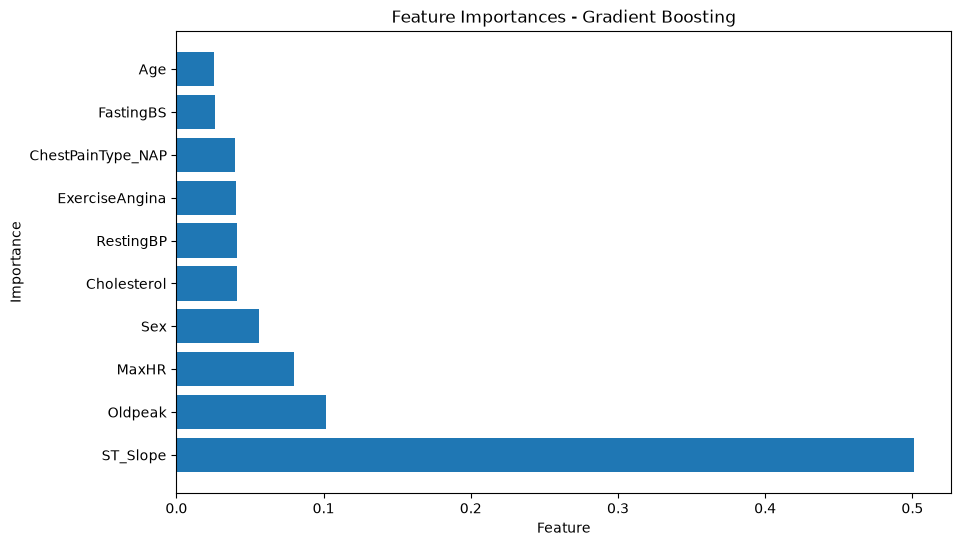

In [155]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"],feature_importance["Importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances - Gradient Boosting")

plt.show()

## Final Model Summary

After testing multiple models, the best final approach was:

- **Model**: Gradient Boosting Classifier
- **Preprocessing**:
  - StandardScaler
  - KNNImputer
- **Evaluation focus**: Recall
- **Selected threshold**: 0.30

Because this is a medical classification problem, the main goal was to reduce false negatives.  
A false negative means a patient with heart disease was predicted as healthy, which is the most dangerous error in this project.

The default threshold of 0.50 produced more false negatives.  
After threshold tuning, the threshold of 0.30 reduced false negatives and improved recall.

The final model achieved:

- High recall for heart disease cases
- Good F1-score
- Acceptable precision
- Fewer missed heart disease patients

Feature importance showed that the model relied mostly on ECG and exercise-related features, especially:

- ST_Slope
- Oldpeak
- MaxHR

Feature engineering was also tested, but it did not improve recall or reduce false negatives, so the simpler final pipeline was selected.

In [156]:
final_results = pd.DataFrame([
    {
        "Model": "Gradient Boosting + Threshold 0.30",
        "Accuracy": accuracy_score(y_test, y_pred_final),
        "Recall": recall_score(y_test, y_pred_final),
        "Precision": precision_score(y_test, y_pred_final),
        "F1": f1_score(y_test, y_pred_final),
        "False Negatives": confusion_matrix(y_test, y_pred_final).ravel()[2],
        "False Positives": confusion_matrix(y_test, y_pred_final).ravel()[1]
    }
])

final_results

,Model,Accuracy,Recall,Precision,F1,False Negatives,False Positives
0,Gradient Boosting + Threshold 0.30,0.858696,0.911765,0.845455,0.877358,9,17
